## Agentic RAG 구현 전, 잘 못된 법률을 찾아옴. 해석이 틀림. 후속 개선 예정

목표 : AI Agent 개발을 위한 LangChian, LangGraph 실습하기

목적 : 도로교통법을 해석해서 질문에 답해주기


주요기능
1. 사용자가 자동차 운전자 사이의 다툼, 사고 등 도로교통법에 관련된 질문을 하면 도로교통법 법률과 판례, 사례를 근거로 상황을 해석해서 답변한다.
2. 사용자가 도로교통법과 무관한 질문을 하면 도로교통법에 관한 질문을 해달라고 답변한다.
3. 필요하면 사례를 웹 검색하여 링크를 제공한다.


부가기능
1. 사용자별 세션 구분을 위한 id 사용한다 (사용자 최대 3)
2. 각 세션 별 context 유지를 위한 메모리 사용한다


Tool Calling
1. RAG
2. DuckDuckGo websearch


Flow
1. 질문을 input() 으로 입력 받음.
2. 질문과 유사도가 높은 법률을 '도로교통법_법률_제21246호.pdf' 에서 검색하여 법률 번호 확인.
3. 단순 법률 해석 질문이면 검색된 법률 번호 함께 내용 일반인 대상으로 재해석하여 설명을 출력.
4. 법률 위반인지 판단이 필요하면 질문·조문과 유사한 판례를 '판례목록' Chroma에서 검색해 해석.
5. '판례목록.txt' 에 관련 내용이 없다면 웹 에서 유사 사례를 검색.
6. 판례, 유사 사례가 없다고 판단되면 '판례 및 사례를 찾을 수 없습니다.' 출력.


문서 폴더 경로 : .\simple_lang1_dataset\

---
## PoC 구현 가이드 (입문자용)
아래 셀을 **위에서부터 순서대로** 실행하세요.

```
질문 입력
   ↓
관련성 판단 (triage)
   ├─ 관련 → 법률 RAG 검색 → (아래 유형 분류로)
   ├─ 반복·모호·겉보기 무관 + 이전 문맥으로 추정 가능 → 역질문(clarify) → 종료
   │         └─ (다음 사용자 답변) → triage 재실행 → retrieve / reject
   └─ 역질문 불가 기준에 해당 → 거절(reject) → 종료

질문 유형 분류 (retrieve 이후)
   ├─ 단순 해석 → 법률 설명 → 종료
   └─ 위반 판단 → 판례목록 검색
                   ├─ 있음 → 판례 해설 → 종료
                   └─ 없음 → 웹 검색
                               ├─ 있음 → 사례+링크 → 종료
                               └─ 없음 → "판례 및 사례를 찾을 수 없습니다."
```


### Step 0. 패키지 설치 (처음 1회만)
* day4 RAG / day15 LangGraph / day16 Chroma·웹검색에서 쓰던 패키지입니다.

In [37]:
# 필요한 패키지 설치 (이미 설치되어 있으면 건너뛰어도 됩니다)
#%pip install -q langchain langchain-openai langchain-community langchain-chroma langchain-text-splitters langgraph pypdf chromadb ddgs python-dotenv

### Step 1. 환경 변수 · 경로 설정
* `.env`의 `OPENAI_API_KEY`를 읽고, 데이터/Chroma 저장 경로를 정합니다.
* `REBUILD_CHROMA=True`이면 PDF·판례목록을 다시 임베딩합니다.


In [38]:
import os
from pathlib import Path

from dotenv import load_dotenv

# 프로젝트 루트(.env)와 현재 폴더 모두 시도
load_dotenv()
load_dotenv(Path.cwd().parent / '.env')

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
assert OPENAI_API_KEY, 'OPENAI_API_KEY가 없습니다. .env 파일을 확인하세요.'

# 이 노트북이 있는 폴더 기준 경로
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'simple_lang1_dataset'
PDF_PATH = DATA_DIR / '도로교통법_법률_제21246호.pdf'
CASE_PATH = DATA_DIR / '판례목록.txt'
CHROMA_DIR = BASE_DIR / 'chroma_traffic_law'   # 법률 PDF 임베딩
CHROMA_CASE_DIR = BASE_DIR / 'chroma_case_list'  # 판례목록 임베딩

# PDF/판례목록을 수정했을 때만 True로 바꿔 Chroma를 다시 만듭니다.
REBUILD_CHROMA = False

print('BASE_DIR :', BASE_DIR)
print('PDF      :', PDF_PATH.exists(), PDF_PATH.name)
print('CASE     :', CASE_PATH.exists(), CASE_PATH.name)
print('CHROMA_LAW :', CHROMA_DIR)
print('CHROMA_CASE:', CHROMA_CASE_DIR)



BASE_DIR : c:\Users\Admin\Desktop\AI Autonomous\cursor\doitmyself
PDF      : True 도로교통법_법률_제21246호.pdf
CASE     : True 판례목록.txt
CHROMA_LAW : c:\Users\Admin\Desktop\AI Autonomous\cursor\doitmyself\chroma_traffic_law
CHROMA_CASE: c:\Users\Admin\Desktop\AI Autonomous\cursor\doitmyself\chroma_case_list


### Step 2. LLM 준비
* 답변 생성·분류에 사용할 Chat 모델을 만듭니다. (day14/15와 동일 패턴)

In [39]:
from langchain_openai import ChatOpenAI

# temperature=0 → 분류/판단이 비교적 안정적
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0, api_key=OPENAI_API_KEY)
print('LLM ready:', llm.model_name)

LLM ready: gpt-4o-mini


### Step 3. RAG용 벡터스토어 만들기 (Tool 1)
* day4 / day16 패턴: **PDF 로드 → 청크 분할 → 임베딩 → Chroma 저장**
* 한 번 만들면 `CHROMA_DIR`에 저장되어, 다음 실행부터는 바로 불러옵니다.

In [40]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


def build_or_load_vectorstore():
    """도로교통법 PDF를 ChromaDB로 만들거나, 이미 있으면 불러옵니다."""
    embedding = OpenAIEmbeddings(
        model='text-embedding-3-small',
        api_key=OPENAI_API_KEY,
    )

    has_store = CHROMA_DIR.exists() and any(CHROMA_DIR.iterdir())
    if has_store and not REBUILD_CHROMA:
        print('기존 Chroma 로드:', CHROMA_DIR)
        return Chroma(
            persist_directory=str(CHROMA_DIR),
            embedding_function=embedding,
        )

    if has_store and REBUILD_CHROMA:
        print('REBUILD_CHROMA=True → 법률 Chroma 재구축 중...')
    else:
        print('PDF → Chroma 새로 구축 중...')
    pages = PyPDFLoader(str(PDF_PATH)).load()

    # 긴 법률 문서를 검색하기 쉬운 작은 덩어리로 자름
    splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
    chunks = splitter.split_documents(pages)

    store = Chroma.from_documents(
        documents=chunks,
        embedding=embedding,
        persist_directory=str(CHROMA_DIR),
        collection_metadata={'hnsw:space': 'cosine'},
    )
    print(f'완료: pages={len(pages)}, chunks={len(chunks)}')
    return store


vectorstore = build_or_load_vectorstore()

# 간단 테스트: 유사 조문 1개만 확인
demo = vectorstore.similarity_search('음주운전 처벌', k=1)
print('--- 검색 샘플 ---')
print(demo[0].page_content[:300])


기존 Chroma 로드: c:\Users\Admin\Desktop\AI Autonomous\cursor\doitmyself\chroma_traffic_law
--- 검색 샘플 ---
법제처                                                            50                                                       국가법령정보센터
도로교통법
4. 제111조를 위반하여 수강료등의 반환 등 교육생 보호를 위하여 필요한 조치를 하지 아니한 사람
5. 제112조를 위반하여 학원이나 전문학원의 휴원 또는 폐원 신고를 하지 아니한 사람
6. 제115조제1항에 따른 간판이나 그 밖의 표지물 제거, 시설물의 설치 또는 게시문의 부착을 거부ㆍ방해 


### Step 4. 판례목록 벡터스토어 (Chroma)
* `판례목록.txt` 각 줄을 문서로 임베딩해 `CHROMA_CASE_DIR`에 저장합니다.
* 검색은 **질문-판례 유사도(임베딩)** 로 찾습니다.
* `REBUILD_CHROMA=True`이면 판례 Chroma도 다시 만듭니다.


In [41]:
from langchain_core.documents import Document

# 관련 없는 판례가 웹 분기로 못 가게 막는 최소 유사도 (0~1, 높을수록 엄격)
# 기존 0.35에서 0.40으로 소폭 강화했습니다. 아래 점수 점검 결과로 다시 조정할 수 있습니다.
CASE_SCORE_THRESHOLD = 0.40


def build_or_load_case_vectorstore():
    """판례목록.txt를 ChromaDB로 만들거나, 이미 있으면 불러옵니다."""
    embedding = OpenAIEmbeddings(
        model='text-embedding-3-small',
        api_key=OPENAI_API_KEY,
    )

    has_store = CHROMA_CASE_DIR.exists() and any(CHROMA_CASE_DIR.iterdir())
    if has_store and not REBUILD_CHROMA:
        print('기존 판례 Chroma 로드:', CHROMA_CASE_DIR)
        return Chroma(
            persist_directory=str(CHROMA_CASE_DIR),
            embedding_function=embedding,
            collection_name='traffic_cases',
        )

    if has_store and REBUILD_CHROMA:
        print('REBUILD_CHROMA=True → 판례 Chroma 재구축 중...')
    else:
        print('판례목록.txt → Chroma 새로 구축 중...')
    lines = [
        line.strip()
        for line in CASE_PATH.read_text(encoding='utf-8').splitlines()
        if line.strip()
    ]
    docs = [
        Document(page_content=line, metadata={'line_no': i})
        for i, line in enumerate(lines, start=1)
    ]

    store = Chroma.from_documents(
        documents=docs,
        embedding=embedding,
        persist_directory=str(CHROMA_CASE_DIR),
        collection_name='traffic_cases',
        collection_metadata={'hnsw:space': 'cosine'},
    )
    print(f'완료: cases={len(docs)} → {CHROMA_CASE_DIR}')
    return store


case_vectorstore = build_or_load_case_vectorstore()


def search_cases(query: str, top_n: int = 5, min_score: float | None = None) -> list[str]:
    """질문과 임베딩 유사도가 높은 판례 줄을 최대 top_n개 반환합니다."""
    # 기본값을 함수 실행 시 읽어, CASE_SCORE_THRESHOLD를 나중에 바꿔도 바로 반영되게 함
    threshold = CASE_SCORE_THRESHOLD if min_score is None else min_score
    pairs = case_vectorstore.similarity_search_with_relevance_scores(query, k=top_n)
    hits = []
    for doc, score in pairs:
        print(f'  [case score={score:.3f}]', doc.page_content[:80].replace('\n', ' '), '...')
        if score >= threshold:
            hits.append(doc.page_content)
    return hits


def inspect_case_scores(queries: list[str]) -> None:
    """여러 테스트 질문의 최고 판례 유사도를 보여주어 threshold 조정을 돕습니다."""
    print('현재 threshold:', CASE_SCORE_THRESHOLD)
    for query in queries:
        pairs = case_vectorstore.similarity_search_with_relevance_scores(query, k=1)
        score = pairs[0][1] if pairs else 0.0
        passed = score >= CASE_SCORE_THRESHOLD
        print(f'{query!r:24} → top_score={score:.3f}, 판례 분기={passed}')


# threshold 점검: 관련 질문은 True, 무관 질문은 False가 되는지 확인
inspect_case_scores([
    '음주운전 사고 처벌 판례',
    '무면허 운전 중 사고가 났어요',
    '파이썬 리스트를 정렬하는 방법',
])



기존 판례 Chroma 로드: c:\Users\Admin\Desktop\AI Autonomous\cursor\doitmyself\chroma_case_list
현재 threshold: 0.4
'음주운전 사고 처벌 판례'          → top_score=0.435, 판례 분기=True
'무면허 운전 중 사고가 났어요'       → top_score=0.489, 판례 분기=True
'파이썬 리스트를 정렬하는 방법'       → top_score=0.232, 판례 분기=False


### Step 5. 웹 검색 함수 (Tool 2)
* day16과 같이 `ddgs`(DuckDuckGo)로 유사 사례를 찾습니다.
* 결과에는 **제목·요약·링크**가 포함됩니다.

In [42]:
from ddgs import DDGS
from ddgs.exceptions import DDGSException


def web_search_cases(query: str, max_results: int = 3) -> list[dict]:
    """질문에 대한 웹 검색 결과(dict 리스트)를 반환합니다. 실패 시 빈 리스트."""
    try:
        with DDGS() as ddgs:
            # 도로교통 사례에 더 잘 맞게 검색어를 조금 보강
            q = f'도로교통법 {query} 판례 OR 사례'
            return list(ddgs.text(q, max_results=max_results))
    except DDGSException as e:
        print('웹 검색 실패:', e)
        return []


# 간단 테스트 (네트워크 필요)
demo_web = web_search_cases('신호위반 사고 과실', max_results=2)
print('웹 결과 개수:', len(demo_web))
if demo_web:
    print(demo_web[0])

웹 결과 개수: 2
{'title': '신호위반 교통사고, 법원은 처벌할 수 없다고 했다 | 로톡', 'href': 'https://www.lawtalk.co.kr/case-lenses/9467', 'body': 'December 27, 2025 - 따라서 사고의 직접적인 원인은 운전자가 전방을 잘 살피지 않아 차선을 바꾸는 자전거를 보지 못한 과실 때문이지, 신호위반 자체는 아니라고 판단했답니다.'}


### Step 6. Agent State 정의
* LangGraph에서 노드들이 공유하는 **한 장의 메모장**입니다.
* 노드가 `return {'필드': 값}` 하면 State가 갱신됩니다. (day15 패턴)
* `history_text`: 요약 + 최근 대화를 합친 문맥 (triage·답변 노드 공통)
* `triage_route`: triage 후 분기 (`retrieve` / `clarify` / `reject`)


In [43]:
from typing import Literal
from pydantic import BaseModel, Field


class AgentState(BaseModel):
    """도로교통법 Agent가 질문 하나를 처리하는 동안 들고 다니는 상태."""
    session_id: str = 'user1'          # 사용자 구분 (최대 3명)
    question: str = ''                 # 이번 질문
    history_text: str = ''             # 이전 대화 텍스트 (문맥 추론용)
    awaiting_clarify: bool = False     # 직전 AI 역질문에 대한 사용자 답변인가?
    clarify_attempts: int = 0          # 현재 주제에서 이미 한 역질문 횟수
    is_traffic: bool = False           # 도로교통 관련 질문인가?
    triage_route: Literal['retrieve', 'clarify', 'reject'] = 'reject'
    law_docs: list[str] = Field(default_factory=list)  # RAG로 찾은 법률 조각
    need_case: bool = False            # 위반 판단(판례)이 필요한가?
    case_hits: list[str] = Field(default_factory=list)  # 판례목록 검색 결과
    web_hits: list[dict] = Field(default_factory=list)  # 웹 검색 결과
    answer: str = ''                   # 최종 답변
    source: Literal['reject', 'clarify', 'law', 'case', 'web', 'none', ''] = ''


print(AgentState(question='테스트'))

session_id='user1' question='테스트' history_text='' awaiting_clarify=False clarify_attempts=0 is_traffic=False triage_route='reject' law_docs=[] need_case=False case_hits=[] web_hits=[] answer='' source=''


### Step 7. 노드 함수들
* 각 노드는 **한 가지 일만** 하고, 바꾼 필드만 dict로 반환합니다.
* day15 Node / day16 retrieve·relevance·web_search와 같은 방식입니다.
* triage는 `retrieve` / `clarify`(역질문) / `reject` 중 하나를 고릅니다.


In [44]:
# 한 주제에서 허용할 최대 역질문 횟수
MAX_CLARIFY_ATTEMPTS = 2

# 역질문을 만들기 어려운 상태 (= 바로 reject) 판단 기준
HARD_TO_CLARIFY_RULES = """
[역질문 불가 기준 — 하나라도 해당하면 REJECT]
1) 이전 대화(history)가 비어 있다.
2) 이전 대화에 도로교통/운전/사고/신호/과실/처벌 등 관련 내용이 전혀 없다.
3) 현재 입력이 빈 내용, 이모지만, 의미 없는 문자열, 1글자 수준이다.
4) 이전 대화와 현재 입력 사이에 연결 가능한 도로교통 주제 후보가 없다.
5) 허용된 최대 역질문 횟수를 이미 사용했다.
"""


def _parse_route(text: str) -> str:
    """LLM 출력에서 RETRIEVE/CLARIFY/REJECT를 뽑습니다."""
    raw = (text or '').strip().upper()
    for key in ('RETRIEVE', 'CLARIFY', 'REJECT'):
        if key in raw:
            return key.lower()
    return 'reject'


def _context_block(state: AgentState) -> str:
    """답변·분류 노드 프롬프트에 넣을 대화 문맥. history_text가 비어 있으면 안내 문구."""
    text = (state.history_text or '').strip()
    return text if text else '(이전 대화 없음)'


def _search_query(state: AgentState) -> str:
    """RAG/판례 검색 쿼리. 후속 질문(지시어·생략)은 최근 문맥을 붙여 검색합니다."""
    ctx = (state.history_text or '').strip()
    if not ctx:
        return state.question
    # 토큰 절약: 검색용으로는 문맥 뒷부분만 사용
    tail = ctx[-900:] if len(ctx) > 900 else ctx
    return f'이전 대화:\n{tail}\n\n현재 질문: {state.question}'


def triage_node(state: AgentState) -> dict:
    """역할: 관련 여부 판단. 모호하면 제한 횟수 안에서 역질문합니다."""
    history = state.history_text.strip() or '(없음)'

    # 역질문에 대한 답변 턴: 명확하면 retrieve, 아직 모호하면 한 번 더 clarify
    if state.awaiting_clarify:
        can_retry = state.clarify_attempts < MAX_CLARIFY_ATTEMPTS
        retry_rule = (
            '아직 애매하거나 단순히 "아니오", "모르겠어"라고 답했지만 이전 도로교통 주제가 있으면 '
            'ROUTE=CLARIFY로 출력하세요.'
            if can_retry
            else '최대 역질문 횟수를 사용했으므로 CLARIFY는 선택하지 말고 ROUTE=REJECT로 출력하세요.'
        )
        prompt = (
            '당신은 도로교통법 Agent의 triage입니다.\n'
            '직전 AI가 역질문을 했고, 아래는 사용자의 답변입니다.\n'
            '도로교통 관련 의도가 명확해졌으면 ROUTE=RETRIEVE로 출력하세요.\n'
            f'{retry_rule}\n'
            '이전 대화와도 연결되지 않는 무관한 답이면 ROUTE=REJECT로 출력하세요.\n'
            '출력은 ROUTE=RETRIEVE, ROUTE=CLARIFY, ROUTE=REJECT 중 한 줄만 허용됩니다.\n\n'
            f'현재 역질문 횟수: {state.clarify_attempts}/{MAX_CLARIFY_ATTEMPTS}\n'
            f'이전 대화:\n{history}\n\n'
            f'사용자 답변(현재 입력): {state.question}'
        )
        verdict = llm.invoke(prompt).content
        route = _parse_route(verdict)
        if route == 'clarify' and not can_retry:
            route = 'reject'
        ok = route == 'retrieve'
        print('[triage/awaiting_clarify]', verdict.strip(), '→', route)
        return {'is_traffic': ok, 'triage_route': route}

    prompt = (
        '당신은 도로교통법 Agent의 triage입니다.\n'
        '출력은 반드시 한 줄로: ROUTE=RETRIEVE 또는 ROUTE=CLARIFY 또는 ROUTE=REJECT\n\n'
        '[판단 규칙]\n'
        '1) 현재 입력이 명백히 도로교통/운전/사고/법규 관련이면 RETRIEVE\n'
        '2) 과거 질문 반복, 짧거나 모호, 겉보기 무관해도 '
        '이전 대화 문맥으로 도로교통 관련 의도를 추정할 수 있으면 CLARIFY\n'
        '3) 아래 역질문 불가 기준에 해당하면 REJECT (바로 거절)\n\n'
        f'{HARD_TO_CLARIFY_RULES}\n\n'
        f'이전 대화:\n{history}\n\n'
        f'현재 질문: {state.question}'
    )
    verdict = llm.invoke(prompt).content
    route = _parse_route(verdict)
    ok = route == 'retrieve'
    print('[triage]', verdict.strip(), '→', route)
    return {'is_traffic': ok, 'triage_route': route}


def clarify_node(state: AgentState) -> dict:
    """역할: 이전 문맥에서 추정한 도로교통 주제로 역질문 1~2문장 생성."""
    history = state.history_text.strip() or '(없음)'
    retry_hint = (
        '이전 역질문과 다른 표현을 사용하고, 가능한 주제 2개를 선택지로 제시하세요. '
        if state.clarify_attempts > 0
        else ''
    )
    prompt = (
        '당신은 도로교통법 상담 Agent입니다.\n'
        '사용자의 입력이 모호하거나 반복·겉보기 무관합니다.\n'
        '이전 대화 문맥을 보고, 사용자가 말하려는 도로교통 관련 의도를 확인하는 '
        '역질문만 1~2문장 작성하세요.\n'
        f'{retry_hint}'
        '사용자가 짧게 답해도 의도를 구분할 수 있도록 구체적으로 질문하세요.\n'
        '거절하거나 법률 해설을 하지 마세요.\n\n'
        f'이전 대화:\n{history}\n\n'
        f'현재 입력: {state.question}'
    )
    q = llm.invoke(prompt).content.strip()
    print('[clarify]', q[:120])
    return {'answer': q, 'source': 'clarify'}


def reject_node(state: AgentState) -> dict:
    """역할: 역질문도 어려우면 도로교통 질문을 부탁하는 안내문 반환."""
    msg = (
        '도로교통법과 관련된 질문만 답변할 수 있어요. '
        '예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등'
    )
    print('[reject]', msg)
    return {'answer': msg, 'source': 'reject'}



In [45]:
def retrieve_node(state: AgentState) -> dict:
    """역할: 질문과 비슷한 도로교통법 조문을 Chroma(RAG)에서 검색."""
    # 후속 질문은 문맥을 붙여 검색 (예: "그거 벌금은?" → 이전 주제 반영)
    query = _search_query(state)
    hits = vectorstore.similarity_search(query, k=4)
    docs = [d.page_content for d in hits]
    print('[retrieve] hits:', len(docs))
    for i, d in enumerate(docs, 1):
        print(f'  ({i})', d[:80].replace('\n', ' '), '...')
    return {'law_docs': docs}


def classify_node(state: AgentState) -> dict:
    """역할: 법률 설명(LAW)과 구체적 사건 판단(CASE)을 구분합니다."""
    ctx = _context_block(state)
    prompt = (
        '다음 질문을 LAW 또는 CASE 중 하나로 분류하세요. 다른 말은 쓰지 마세요.\n'
        '이전 대화가 있으면 후속 질문의 의도도 함께 고려하세요.\n\n'
        '[LAW]\n'
        '- 법 조항, 처벌 기준, 용어의 의미를 일반적으로 묻는 질문\n'
        '- 구체적인 당사자·사고 상황의 판단을 요구하지 않는 질문\n'
        '- 예: "음주운전 처벌 기준이 뭐야?", "신호위반은 어떤 법 위반이야?"\n\n'
        '[CASE]\n'
        '- 실제 사고·다툼에서 누가 위반했는지, 과실·책임·처벌 가능성을 판단하는 질문\n'
        '- 예: "빨간불에 진입한 A와 과속한 B 중 누구 과실이 커?"\n\n'
        f'이전 대화:\n{ctx}\n\n'
        f'질문: {state.question}'
    )
    raw = llm.invoke(prompt).content.strip().upper()
    label = 'CASE' if raw.startswith('CASE') else 'LAW'
    need = label == 'CASE'
    print('[classify]', label, '→ need_case=', need)
    return {'need_case': need}



In [46]:
def _short_text(text: str, limit: int = 180) -> str:
    """근거 표시에 사용할 문장을 한 줄로 짧게 정리합니다."""
    clean = ' '.join(text.split())
    return clean[:limit] + ('...' if len(clean) > limit else '')


def interpret_node(state: AgentState) -> dict:
    """역할: RAG로 찾은 조문을 일반인이 읽기 쉽게 재해석."""
    ctx = _context_block(state)
    context = '\n\n'.join(state.law_docs)
    prompt = (
        '당신은 도로교통법 해설가입니다. 아래 법률 조문을 근거로 질문에 답하세요.\n'
        '이전 대화가 있으면 후속 질문의 "그거", "그 경우" 등을 문맥에 맞게 해석하세요.\n'
        '관련 조문 번호가 보이면 반드시 함께 적고, 쉬운 말로 2~5문장 설명하세요.\n'
        '제공된 법률에 없는 내용은 단정하지 마세요.\n\n'
        f'이전 대화:\n{ctx}\n\n'
        f'법률:\n{context}\n\n질문: {state.question}'
    )
    body = llm.invoke(prompt).content.strip()

    # LLM 응답과 별도로, 실제 RAG 검색 결과를 근거로 확정 표시
    grounds = '\n'.join(
        f'- 법률 PDF 검색 결과 {i}: {_short_text(doc)}'
        for i, doc in enumerate(state.law_docs[:2], 1)
    )
    answer = f'{body}\n\n[근거]\n{grounds}'

    print('[interpret] 법률 해설 생성 완료')
    return {'answer': answer, 'source': 'law'}



In [47]:
def case_lookup_node(state: AgentState) -> dict:
    """역할: 질문(+법률 조각)을 임베딩해 유사 판례를 Chroma에서 검색."""
    query = _search_query(state)
    law_hint = '\n'.join(state.law_docs[:2]) if state.law_docs else ''
    if law_hint:
        query = f'{query}\n\n관련 조문:\n{law_hint[:500]}'

    hits = search_cases(query, top_n=5)
    print('[case_lookup] hits=', len(hits), '(threshold=', CASE_SCORE_THRESHOLD, ')')
    return {'case_hits': hits}


def case_answer_node(state: AgentState) -> dict:
    """역할: 찾은 판례 목록 + 법률 조각을 바탕으로 상황 해석."""
    ctx = _context_block(state)
    law = '\n\n'.join(state.law_docs)
    cases = '\n'.join(state.case_hits)
    prompt = (
        '법률과 판례 제목을 참고해 일반인이 이해하기 쉽게 답하세요.\n'
        '이전 대화가 있으면 후속 질문을 문맥에 맞게 이어서 답하세요.\n'
        '판례 제목만으로 확정적인 판결 내용을 추측하지 말고, 참고 사례라고 표현하세요.\n'
        '제공된 법률·판례 목록에 없는 내용은 단정하지 마세요.\n\n'
        f'이전 대화:\n{ctx}\n\n'
        f'법률:\n{law}\n\n판례목록:\n{cases}\n\n질문: {state.question}'
    )
    body = llm.invoke(prompt).content.strip()

    law_ground = _short_text(state.law_docs[0]) if state.law_docs else '검색 결과 없음'
    case_grounds = '\n'.join(f'- 판례 후보: {case}' for case in state.case_hits[:2])
    answer = (
        f'{body}\n\n[근거]\n'
        f'- 법률 PDF 검색 결과: {law_ground}\n'
        f'{case_grounds}'
    )

    print('[case_answer] 판례 기반 답변 생성 완료')
    return {'answer': answer, 'source': 'case'}



In [48]:
def web_search_node(state: AgentState) -> dict:
    """역할: 판례목록에 없으면 웹 검색. 결과 없거나 부적절하면 안내 문구."""
    ctx = _context_block(state)
    # 검색어에도 문맥 반영 (후속 질문 대응)
    search_q = _search_query(state)
    results = web_search_cases(search_q, max_results=3)
    print('[web_search] hits=', len(results))

    if not results:
        msg = '판례 및 사례를 찾을 수 없습니다.\n\n[근거]\n- 웹 검색 결과 없음'
        return {'web_hits': [], 'answer': msg, 'source': 'none'}

    # 링크가 보이도록 검색 결과를 텍스트로 정리
    lines = []
    for r in results:
        title = r.get('title', '')
        body = r.get('body', '')
        href = r.get('href', '')
        lines.append(f'- {title}\n  {body}\n  링크: {href}')
    context = '\n'.join(lines)

    prompt = (
        '내부 판례목록에서 못 찾아 웹 검색했습니다. 결과를 참고해 답하세요.\n'
        '이전 대화가 있으면 후속 질문을 문맥에 맞게 이어서 답하세요.\n'
        '관련성이 불확실하면 단정하지 말고, 관련 없으면 '
        '"판례 및 사례를 찾을 수 없습니다."라고 답하세요.\n\n'
        f'이전 대화:\n{ctx}\n\n'
        f'검색결과:\n{context}\n\n질문: {state.question}'
    )
    body = llm.invoke(prompt).content.strip()
    is_none = '판례 및 사례를 찾을 수 없습니다' in body

    if is_none:
        answer = f'{body}\n\n[근거]\n- 웹 검색 결과가 질문과 관련 없다고 판단됨'
        source = 'none'
    else:
        links = '\n'.join(
            f"- {r.get('title', '제목 없음')}: {r.get('href', '링크 없음')}"
            for r in results
        )
        answer = f'{body}\n\n[근거]\n{links}'
        source = 'web'

    return {'web_hits': results, 'answer': answer, 'source': source}



### Step 8. 라우터 (Conditional Edge)
* day15 `judge_route`처럼, **다음에 갈 노드 이름**만 반환합니다.
* triage 이후: `retrieve` / `clarify` / `reject`


In [49]:
from langgraph.graph import START, END


def route_after_triage(state: AgentState) -> str:
    """triage_route에 따라 retrieve / clarify / reject로 분기."""
    route = state.triage_route or 'reject'
    if route not in ('retrieve', 'clarify', 'reject'):
        route = 'reject'
    return route


def route_after_classify(state: AgentState) -> str:
    """단순 해석이면 interpret, 위반 판단이면 case_lookup."""
    return 'case_lookup' if state.need_case else 'interpret'


def route_after_case_lookup(state: AgentState) -> str:
    """판례가 있으면 case_answer, 없으면 web_search."""
    return 'case_answer' if state.case_hits else 'web_search'


### Step 9. Graph 조립 · 컴파일
* 노드를 등록하고, 고정 Edge + Conditional Edge로 흐름을 연결합니다.

In [50]:
from langgraph.graph import StateGraph

workflow = StateGraph(AgentState)

# 1) 노드 등록
workflow.add_node('triage', triage_node)
workflow.add_node('reject', reject_node)
workflow.add_node('clarify', clarify_node)
workflow.add_node('retrieve', retrieve_node)
workflow.add_node('classify', classify_node)
workflow.add_node('interpret', interpret_node)
workflow.add_node('case_lookup', case_lookup_node)
workflow.add_node('case_answer', case_answer_node)
workflow.add_node('web_search', web_search_node)

# 2) 시작 → 관련성 판단 → retrieve / clarify / reject
workflow.add_edge(START, 'triage')
workflow.add_conditional_edges(
    'triage',
    route_after_triage,
    {
        'retrieve': 'retrieve',
        'clarify': 'clarify',
        'reject': 'reject',
    },
)

# 3) 거절·역질문은 종료 / 검색 후 분류
workflow.add_edge('reject', END)
workflow.add_edge('clarify', END)
workflow.add_edge('retrieve', 'classify')
workflow.add_conditional_edges('classify', route_after_classify)

# 4) 해석 종료 / 판례 분기
workflow.add_edge('interpret', END)
workflow.add_conditional_edges('case_lookup', route_after_case_lookup)
workflow.add_edge('case_answer', END)
workflow.add_edge('web_search', END)

app = workflow.compile()
print('Graph compiled')


Graph compiled


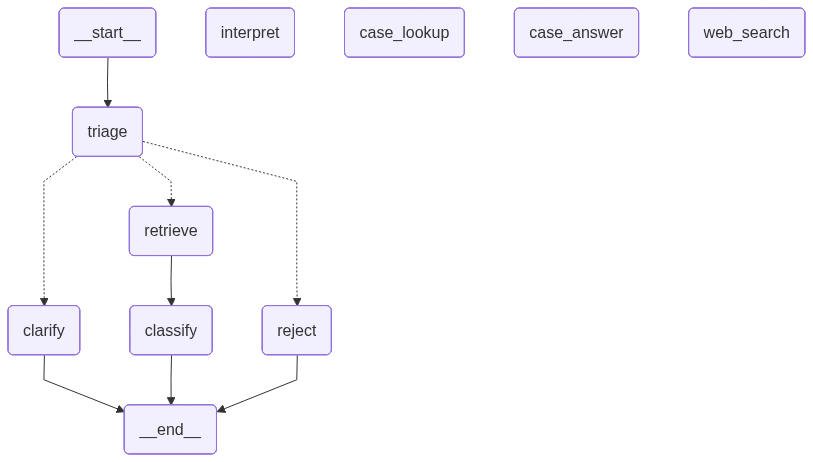

In [51]:
app

### Step 10. 세션 메모리 (최대 3명)
* day14 `ChatSession`처럼 **딕셔너리로 사용자별 대화 이력**을 보관합니다.
* **장기 문맥**: 오래된 대화는 `context_summary`로 압축, 최근 5턴은 원문 유지.
* `prepare_graph_input` / `save_session_turn` / `run_turn`으로 역할을 나눴습니다.
* `run_turn()`은 Slack·FastAPI에서 그대로 재사용할 수 있는 API 형태입니다.


In [52]:
from langchain_core.messages import HumanMessage, AIMessage

MAX_USERS = 3
SESSIONS: dict[str, list] = {}  # {session_id: [HumanMessage, AIMessage, ...]}
SESSION_FLAGS: dict[str, dict] = {}

# --- 대화 문맥 튜닝 상수 ---
# 최근 N개 메시지(= N/2 턴)는 원문 그대로 LLM에 전달
RECENT_MESSAGE_LIMIT = 10          # 5턴
# 이 개수를 넘으면 오래된 원문을 요약으로 압축
SUMMARY_TRIGGER_MESSAGES = 12      # 6턴
# 요약 후에도 세션에 남길 최대 메시지 수 (메모리 폭주 방지)
MAX_STORED_MESSAGES = 30
# 요약문 최대 길이 (토큰 절약)
SUMMARY_MAX_CHARS = 600


def _new_session_flags() -> dict:
    """새 세션이 사용할 기본 상태. context_summary = 장기 기억."""
    return {
        'awaiting_clarify': False,
        'last_clarify': '',
        'clarify_attempts': 0,
        'context_summary': '',
    }


def _reset_clarify_flags(flags: dict) -> None:
    """한 흐름 종료 시 역질문 상태만 초기화 (요약은 유지)."""
    flags['awaiting_clarify'] = False
    flags['last_clarify'] = ''
    flags['clarify_attempts'] = 0


def get_or_create_session(session_id: str) -> list:
    """session_id에 해당하는 대화 이력을 가져오거나 새로 만듭니다. (최대 3명)"""
    if session_id in SESSIONS:
        return SESSIONS[session_id]

    if len(SESSIONS) >= MAX_USERS:
        raise ValueError(
            f'사용자는 최대 {MAX_USERS}명입니다. 현재: {list(SESSIONS.keys())}'
        )

    SESSIONS[session_id] = []
    SESSION_FLAGS[session_id] = _new_session_flags()
    print('[session] 생성:', session_id)
    return SESSIONS[session_id]


def clear_session(session_id: str) -> None:
    """현재 세션의 대화 이력·요약·역질문 상태를 모두 초기화합니다."""
    get_or_create_session(session_id)
    SESSIONS[session_id] = []
    SESSION_FLAGS[session_id] = _new_session_flags()
    print(f'[session] 리셋 완료: {session_id}')


def _messages_to_text(messages: list, limit: int | None = None) -> str:
    """메시지 리스트를 "사용자: ... / AI: ..." 텍스트로 변환."""
    target = messages[-limit:] if limit else messages
    bits = []
    for m in target:
        role = '사용자' if isinstance(m, HumanMessage) else 'AI'
        bits.append(f'{role}: {m.content}')
    return '\n'.join(bits)


def _build_history_context(summary: str, history: list) -> str:
    """장기 요약 + 최근 원문을 하나의 history_text로 합칩니다."""
    recent = _messages_to_text(history, limit=RECENT_MESSAGE_LIMIT)
    parts = []
    if (summary or '').strip():
        parts.append(f'[이전 대화 요약]\n{summary.strip()}')
    if recent.strip():
        parts.append(f'[최근 대화]\n{recent}')
    return '\n\n'.join(parts)


def _summarize_messages(old_text: str, prev_summary: str) -> str:
    """오래된 대화 원문을 요약해 context_summary에 누적합니다."""
    prompt = (
        '당신은 도로교통법 상담 대화 요약기입니다.\n'
        '아래 이전 요약과 새로운 대화를 합쳐, 도로교통 관련 핵심만 3~5문장으로 요약하세요.\n'
        '사용자가 물은 주제, 사고 상황, 법규 키워드, AI가 답한 요지를 남기세요.\n'
        f'최대 {SUMMARY_MAX_CHARS}자 이내로 작성하세요.\n\n'
        f'기존 요약:\n{prev_summary or "(없음)"}\n\n'
        f'새로 요약할 대화:\n{old_text}'
    )
    text = llm.invoke(prompt).content.strip()
    if len(text) > SUMMARY_MAX_CHARS:
        text = text[:SUMMARY_MAX_CHARS] + '...'
    return text


def maybe_compress_session_history(session_id: str) -> None:
    """대화가 길어지면 오래된 원문 → 요약으로 압축 (rolling summary)."""
    history = SESSIONS.get(session_id, [])
    if len(history) <= SUMMARY_TRIGGER_MESSAGES:
        return

    flags = SESSION_FLAGS.setdefault(session_id, _new_session_flags())
    # 최근 RECENT_MESSAGE_LIMIT개는 원문 유지, 그 앞은 요약 대상
    to_summarize = history[:-RECENT_MESSAGE_LIMIT]
    if not to_summarize:
        return

    old_text = _messages_to_text(to_summarize)
    flags['context_summary'] = _summarize_messages(
        old_text,
        flags.get('context_summary', ''),
    )
    # 요약한 원문은 세션에서 제거 → 메모리·토큰 절약
    SESSIONS[session_id] = history[-RECENT_MESSAGE_LIMIT:]
    # 혹시 모를 폭주 방지
    if len(SESSIONS[session_id]) > MAX_STORED_MESSAGES:
        SESSIONS[session_id] = SESSIONS[session_id][-MAX_STORED_MESSAGES:]

    print(
        f'[context] 요약 갱신 ({session_id}): '
        f'남은 메시지 {len(SESSIONS[session_id])}개, '
        f'요약 {len(flags["context_summary"])}자'
    )


def prepare_graph_input(session_id: str, question: str) -> tuple[AgentState, list, dict]:
    """세션 history를 반영해 Graph에 넣을 AgentState를 만듭니다."""
    history = get_or_create_session(session_id)
    flags = SESSION_FLAGS.setdefault(session_id, _new_session_flags())
    awaiting = bool(flags.get('awaiting_clarify'))
    attempts = int(flags.get('clarify_attempts', 0))

    # 요약 + 최근 원문 → 모든 노드가 공유하는 문맥
    history_text = _build_history_context(flags.get('context_summary', ''), history)
    if awaiting and flags.get('last_clarify'):
        history_text = (
            history_text
            + ('\n\n' if history_text else '')
            + f'[직전 역질문]\n{flags["last_clarify"]}'
        )

    graph_question = question
    if awaiting:
        graph_question = (
            f'사용자 확인/답변: {question}\n'
            f'직전 역질문: {flags.get("last_clarify", "")}\n'
            '위 내용을 이전 도로교통 대화에 이어지는 답변으로 해석하세요.'
        )

    state = AgentState(
        session_id=session_id,
        question=graph_question,
        history_text=history_text,
        awaiting_clarify=awaiting,
        clarify_attempts=attempts,
    )
    return state, history, flags


def save_session_turn(session_id: str, question: str, answer: str, source: str) -> None:
    """한 턴의 질문/답변을 history와 SESSION_FLAGS에 저장합니다."""
    history = SESSIONS[session_id]
    flags = SESSION_FLAGS.setdefault(session_id, _new_session_flags())

    history.append(HumanMessage(content=question))
    history.append(AIMessage(content=answer))

    if source == 'clarify':
        flags['awaiting_clarify'] = True
        flags['last_clarify'] = answer
        flags['clarify_attempts'] = int(flags.get('clarify_attempts', 0)) + 1
    else:
        _reset_clarify_flags(flags)

    # 답변 저장 후, 길어진 history를 요약으로 압축
    maybe_compress_session_history(session_id)


def run_turn(session_id: str, question: str) -> dict:
    """한 턴을 실행하고 dict로 반환합니다. (Slack/FastAPI 연동용)"""
    state, history, flags = prepare_graph_input(session_id, question)
    result = app.invoke(state)
    answer = result['answer'] if isinstance(result, dict) else result.answer
    source = result['source'] if isinstance(result, dict) else result.source
    save_session_turn(session_id, question, answer, source)
    return {
        'session_id': session_id,
        'question': question,
        'answer': answer,
        'source': source,
        'awaiting_clarify': SESSION_FLAGS[session_id]['awaiting_clarify'],
        'context_summary': SESSION_FLAGS[session_id].get('context_summary', ''),
    }


def ask_agent(session_id: str, question: str) -> str:
    """run_turn()의 answer만 반환하는 간단한 래퍼입니다."""
    return run_turn(session_id, question)['answer']


print('세션 준비 완료. 허용 사용자 수:', MAX_USERS)
print(
    f'문맥 설정: 최근 {RECENT_MESSAGE_LIMIT // 2}턴 원문, '
    f'{SUMMARY_TRIGGER_MESSAGES // 2}턴 이후 요약 압축'
)



세션 준비 완료. 허용 사용자 수: 3
문맥 설정: 최근 5턴 원문, 6턴 이후 요약 압축


### Step 11. 단발 테스트
* 루프 전에 질문 몇 개로 Graph가 잘 도는지 확인합니다.
* A: 이력 없는 무관 질문 → `reject`
* B: 일반적인 처벌 기준 질문 → `LAW` → 법률 답변 + `[근거]`
* C: 구체적인 사고 책임 질문 → `CASE` → 판례 답변 + `[근거]`
* D: 문맥 있는 모호한 입력 → 첫 번째 `clarify`
* E: `아니오`처럼 아직 모호한 답변 → 두 번째 `clarify`
* F: 다시 모호한 답변 → 최대 횟수 도달로 `reject`


In [55]:
# 테스트 전 세션 초기화
SESSIONS.clear()
SESSION_FLAGS.clear()

# A) 이력 없는 무관 질문 → reject
print('==== 테스트 A: 이력 없는 무관 질문 ====')
print(ask_agent('user1', '오늘 점심 뭐 먹을까?'))
print()

# B) 일반적인 법률/처벌 기준 → LAW (판례 검색 없이 법률 근거 표시)
print('==== 테스트 B: 일반 법률 설명 (LAW 기대) ====')
print(ask_agent('user1', '음주운전 처벌 기준이 뭐야?'))
print()

# C) 구체적인 사고의 책임 판단 → CASE (판례 근거 표시)
print('==== 테스트 C: 구체적 사건 판단 (CASE 기대) ====')
print(ask_agent('user2', '빨간불에 진입한 A와 과속한 B가 충돌하면 누구 과실이 더 큰가요?'))
print()

# D) 문맥 있는 모호 입력 → 첫 번째 clarify
print('==== 테스트 D: 첫 번째 역질문 ====')
print(ask_agent('user1', '그거 다시 말해줘'))
print('flags =', SESSION_FLAGS['user1'])
print()

# E) 여전히 모호한 답변 → 두 번째 clarify 허용
print('==== 테스트 E: 두 번째 역질문 ====')
print(ask_agent('user1', '아니오'))
print('flags =', SESSION_FLAGS['user1'])
print()

# F) 또 모호한 답변 → 최대 2회 사용으로 reject
print('==== 테스트 F: 역질문 횟수 초과 ====')
print(ask_agent('user1', '모르겠어'))
print('flags =', SESSION_FLAGS['user1'])


==== 테스트 A: 이력 없는 무관 질문 ====
[session] 생성: user1
[triage] ROUTE=REJECT → reject
[reject] 도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등
도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등

==== 테스트 B: 일반 법률 설명 (LAW 기대) ====
[triage] ROUTE=RETRIEVE → retrieve
[retrieve] hits: 4
  (1) 법제처                                                            23                ...
  (2) 법제처                                                            25                ...
  (3) 법제처                                                            33                ...
  (4) 법제처                                                            16                ...
[classify] LAW → need_case= False
[interpret] 법률 해설 생성 완료
음주운전 처벌 기준은 도로교통법 제44조에 명시되어 있습니다. 이 조문에 따르면, 운전자가 혈중알코올농도가 0.03퍼센트 이상일 경우 술에 취한 상태로 간주되어 운전이 금지됩니다. 즉, 이 기준을 초과하면 음주운전으로 처벌받을 수 있습니다. 경찰은 음주 측정을 통해 이 기준을 확인할 수 있으며, 측정에 응하지 않거나 방해하는 행위도 처벌 대상이 됩니다.

[근거]
- 법률 PDF 검색 결과 1: 법제처 23 국가법령정보센터 도로교통법 4호까지 및 제148조의2에서 같다), 노면전차 또는 자전거를 운전하

### Step 12. `input()` 대화 루프
* 시작할 때 **세션 ID를 한 번** 입력합니다.
* 내부적으로 `run_turn()`을 호출해 `{question, answer, source}` 형태로 처리합니다.
* 대화 중 명령어:
  * `사용자변경` → 다른 세션 ID로 전환 (각 세션 history는 그대로 유지)
  * `세션비우기` → **현재 세션**의 대화·요약·역질문 상태 초기화
  * `종료` → 프로그램 종료
* 세션은 `user1` / `user2` / `user3`만 가능합니다.


In [56]:
print('도로교통법 Agent PoC')
print('명령어: 사용자변경 | 세션비우기 | 종료')
print('세션: user1 / user2 / user3')
print('현재 세션 목록:', list(SESSIONS.keys()) or '(없음)')

session_id = input('세션ID (user1~user3): ').strip() or 'user1'
get_or_create_session(session_id)
print(f'세션 "{session_id}" 에서 대화를 시작합니다.\n')

while True:
    question = input(f'[{session_id} 질문]: ').strip()
    if not question:
        continue

    if question == '종료':
        print('종료합니다.')
        break

    if question == '사용자변경':
        new_id = input('새 세션ID (user1~user3): ').strip()
        if not new_id:
            print('세션ID가 비어 있어 변경하지 않습니다.')
            continue
        try:
            get_or_create_session(new_id)
            session_id = new_id
            print(f'세션을 "{session_id}" 로 변경했습니다. (이전 history 유지)\n')
        except ValueError as e:
            print('오류:', e)
        continue

    if question == '세션비우기':
        clear_session(session_id)
        print(f'세션 "{session_id}" 의 대화·요약·역질문 상태를 비웠습니다.\n')
        continue

    try:
        turn = run_turn(session_id, question)
        label = '역질문' if turn['source'] == 'clarify' else '답변'
        print(f'\n[사용자] ({session_id})\n{turn["question"]}\n')
        print(f'[{label}] ({session_id})\n{turn["answer"]}\n')
    except ValueError as e:
        print('오류:', e)



도로교통법 Agent PoC
명령어: 사용자변경 | 세션비우기 | 종료
세션: user1 / user2 / user3
현재 세션 목록: ['user1', 'user2']
[session] 생성: ㅇㅇ
세션 "ㅇㅇ" 에서 대화를 시작합니다.

[triage] ROUTE=REJECT → reject
[reject] 도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등

[사용자] (ㅇㅇ)
불법주정차 관련 법률

[답변] (ㅇㅇ)
도로교통법과 관련된 질문만 답변할 수 있어요. 예: 음주운전 처벌, 신호위반 과실, 사고 후 미조치 등

[triage] ROUTE=CLARIFY → clarify
[clarify] 불법주차에 대한 구체적인 상황이나 궁금한 점이 있으신가요? 예를 들어, 과태료나 단속 기준에 대해 알고 싶으신가요?

[사용자] (ㅇㅇ)
불법주차

[역질문] (ㅇㅇ)
불법주차에 대한 구체적인 상황이나 궁금한 점이 있으신가요? 예를 들어, 과태료나 단속 기준에 대해 알고 싶으신가요?

[triage/awaiting_clarify] ROUTE=RETRIEVE → retrieve
[retrieve] hits: 4
  (1) 법제처                                                            34                ...
  (2) 법제처                                                            6                 ...
  (3) 법제처                                                            25                ...
  (4) 법제처                                                            17                ...
[classify] LAW → need_case= False
[